In [ ]:
# 이 코드는 RAG 실습에 필요한 라이브러리를 설치하는 명령입니다.
# 맨 앞의 ! = "파이썬이 아니라 터미널 명령(설치 등)을 실행하라"는 Colab/주피터 표시
# pip = 파이썬 라이브러리 설치 도구. 보통 노트북 맨 위에서 한 번만 실행하면 됨

!pip install openai langchain langchain-openai
#   openai           : OpenAI API 호출 (임베딩·LLM)
#   langchain        : RAG·LLM 앱 조립 프레임워크 (본체)
#   langchain-openai : LangChain에서 OpenAI를 쓰게 연결해주는 부품

!pip install langchain-community langchain-text-splitters
#   langchain-community     : PDF 로더·FAISS 등 외부 도구 모음
#   langchain-text-splitters: 문서를 청크로 자르는 도구 (청킹 담당)

!pip install faiss-cpu pypdf koreanize-matplotlib
#   faiss-cpu          : 벡터 검색 엔진(벡터DB). 질문과 가까운 청크를 빠르게 찾음
#   pypdf              : PDF에서 텍스트를 추출하는 도구
#   koreanize-matplotlib: 그래프에서 한글이 깨지지 않게 해줌

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.0/349.0 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 64.8 MB/s eta 0:00:00


Colab Secrets에서 API 키 로드 완료


/tmp/ipykernel_2390/3144872426.py:56: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader            # ① PDF 읽기


임베딩 모델 준비 완료

  단계 1. PDF 자동 다운로드
  다운로드: 여비규정.pdf  (697 KB)
  다운로드: 급여규정.pdf  (333 KB)
  다운로드: 창업지원규정.pdf  (374 KB)

pdf_map 확인:
  여비규정: 정상
  급여규정: 정상
  창업지원규정: 정상

  단계 2. 단일 PDF 개별 호출

-- 여비규정 --
  [/content/pdfs/여비규정.pdf] 38 페이지 로드
  [여비규정] 청크 수: 109  (chunk_size=400)

-- 급여규정 --
  [/content/pdfs/급여규정.pdf] 11 페이지 로드
  [급여규정] 청크 수: 29  (chunk_size=400)

-- 창업지원규정 --
  [/content/pdfs/창업지원규정.pdf] 18 페이지 로드
  [창업지원규정] 청크 수: 49  (chunk_size=400)

[여비규정 단독]  질문: 국내 출장 일비는 얼마인가요?
──────────────────────────────────────────────────────────
답변:
제공된 문서에서 확인할 수 없습니다. 

참고한 조항: 제공된 문서 내용.
──────────────────────────────────────────────────────────
참조 청크 (3개):
  [1] /content/pdfs/여비규정.pdf p.36  |  구분여행기간식비공제횟수숙박비공제횟수정상공무출장기내식 (  )회기내숙박 (  )회회의비 (  )회참가비 (  )회현지제공 (  ...
  [2] /content/pdfs/여비규정.pdf p.31  |  - 32 -
[별표 제9호] 국외출장여비산출서 (전문개정 2021.12.23.)(개정 2022.6.23, 2025. 4. 10...
  [3] /content/pdfs/여비규정.pdf p.36  |  제5조)  1. 연장한 여행기간이 체재일(출장지 도착일로부터 공무출장 종료일)을 초과하는 경우  2. 여행기간 연장 횟수가 회...

[급여규정

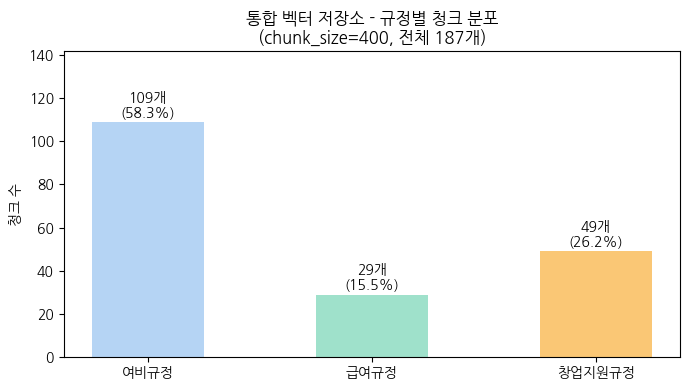


[청크 분포 해석]
  여비규정        : 109개 (58.3%)
  급여규정        :  29개 (15.5%)
  창업지원규정      :  49개 (26.2%)

-> 분량이 많은 규정일수록 청크 수가 많아 검색 시 더 많이 참조됨
-> 여비규정이 58%로 가장 많음 - 복잡한 출장 규정 반영

강사 데모 완료.
다음 단계: NotebookLM 실습 (본인 문서로 동일 흐름 체험)
종합 실습: RFP PDF로 제안서 자동 작성 파이프라인 구현


In [ ]:
# ============================================================
# 실습 3-1. 규정 PDF RAG 파이프라인 (단일/멀티 소스)
# 목표: PDF 로드 -> 청킹 -> 임베딩 -> 검색 -> 생성 전 과정을 체험한다
# 실습 문서: 여비규정.pdf / 급여규정.pdf / 창업지원규정.pdf
# 사전 설치: pip install openai langchain langchain-openai
#            langchain-community langchain-text-splitters
#            faiss-cpu pypdf koreanize-matplotlib
# ============================================================
#
# [무엇을 하려는 코드인가 — 시나리오]
#   현실 문제: 직원이 "출장 일비 얼마예요?"를 알려면 두꺼운 규정집을 뒤져야 함.
#   이 코드의 목표: 챗봇에게 물으면, 규정 PDF에서 근거를 찾아
#                  "○○원입니다 (제5조)"처럼 '출처까지 달아' 답하는 시스템을 만든다.
#   → 즉 "사내 규정 Q&A 챗봇"을 만드는 코드.
#   → hhuk님 고전DB로 치면: "동의보감을 직접 안 뒤지고 처방을 물어보면
#      원문 근거로 답하는 CDSS"와 똑같은 구조. (PDF만 고전 원문으로 바꾸면 됨)
#
# [이 실습이 하는 일 — 한눈에]  ★드디어 진짜 RAG★
#   위 챗봇은 RAG 5단계로 만들어집니다:
#     ① PDF 로드 → ② 청킹(자르기) → ③ 임베딩(벡터로) → ④ 검색 → ⑤ LLM이 답 생성
#   이걸 LangChain(앞서 배운 "RAG 조립 프레임워크")으로 만듭니다.
#   단, 여기선 NotebookLM과 달리 '내가 코드로' 만든다는 점이 다릅니다.
#
# [냉정한 평가 — 한계도 알고 시작]
#   · 이 코드는 '잘 정리된 텍스트 PDF'를 가정함. 표·세로쓰기·스캔본은 추출이 깨짐
#     → 단계 2에서 금액이 '확인 불가'로 나오는 게 바로 그 한계의 증거.
#   · 즉 "RAG가 똑똑한 것"이 아니라 "넣는 문서가 깨끗해야" 작동함.
#     실전에선 전처리(깨끗한 텍스트화)가 절반 이상의 일.
#   · OpenAI 임베딩은 문서를 미국 서버로 보냄 → 기관 미공개 데이터는 부적합.
# ============================================================

import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
plt.rcParams['axes.unicode_minus'] = False
from collections import Counter   # 개수 세기 도구 (5단계 그래프용)

# ── API 키 설정 ──────────────────────────────────────────────
# (앞 실습과 동일: Colab 열쇠 아이콘의 키를 불러옴)
try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    print("Colab Secrets에서 API 키 로드 완료")
except Exception:
    pass
# os.environ["OPENAI_API_KEY"] = "sk-..."

if not os.environ.get("OPENAI_API_KEY"):
    raise ValueError(
        "API 키가 설정되지 않았습니다.\n"
        "방법 A: 왼쪽 사이드바 열쇠 아이콘 -> 'OPENAI_API_KEY' 등록\n"
        "방법 B: os.environ['OPENAI_API_KEY'] = 'sk-...' 주석 해제"
    )

# ── LangChain 부품들 불러오기 (각각이 RAG의 한 단계 담당) ──
from langchain_community.document_loaders import PyPDFLoader            # ① PDF 읽기
from langchain_text_splitters import RecursiveCharacterTextSplitter     # ② 청킹(자르기)
from langchain_openai import OpenAIEmbeddings, ChatOpenAI               # ③ 임베딩 + ⑤ LLM
from langchain_community.vectorstores import FAISS                      # ④ 벡터DB(검색)
from langchain_core.prompts import PromptTemplate                       # 프롬프트 틀
from langchain_core.runnables import RunnablePassthrough                # 체인 연결용
from langchain_core.output_parsers import StrOutputParser               # 결과를 문자열로

# 임베딩 모델 = 텍스트를 벡터로 바꾸는 도구 (앞서 추천한 그 RAG용 모델!)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
print(f"임베딩 모델 준비 완료")


# ============================================================
# [실습 변수] 여기만 수정하여 다양한 실험 가능
# ============================================================

# 청크 크기 = 문서를 몇 글자 단위로 자를지 (앞서 배운 '청킹 전략'의 핵심 손잡이)
# 규정집은 '조항'이 의미의 최소 단위라, 너무 작으면 조항이 잘려 검색이 망가짐
CHUNK_SIZE    = 400
CHUNK_OVERLAP = 50   # 청크끼리 겹치는 양 (경계에서 내용 잘림 방지 — 앞서 말한 'overlap')

# 검색해서 가져올 청크 수 (단일 소스)
K_SINGLE = 3

# 멀티 소스는 참조할 문서가 많으니 더 많이 가져옴
K_MULTI  = 5

# 청크 크기 비교 실험값 (100 vs 400 — 작을 때 vs 적절할 때 차이 확인)
CHUNK_COMPARE = [100, 400]

# 단일 규정 질문들 {규정명: 질문}
SINGLE_QUERIES = {
    "여비규정":    "국내 출장 일비는 얼마인가요?",
    "급여규정":    "연봉 협상 주기는 어떻게 되나요?",
    "창업지원규정": "창업 지원금 신청 요건은 무엇인가요?",
}

# 멀티 소스 질문 = 여러 규정을 동시에 봐야 답할 수 있는 질문
MULTI_QUERIES = [
    "출장 중 창업 관련 활동을 할 경우 여비와 지원금을 동시에 받을 수 있나요?",
    "급여와 관련된 출장 수당 규정이 있나요?",
    "창업 지원 대상자의 급여 처리는 어떻게 되나요?",
]

# 청크 크기 비교용 질문
CHUNK_TEST_QUESTION = "국내 출장 식비 기준을 알려주세요."

# ============================================================
# 이하 코드는 수정 불필요  (← 흐름만 이해하고 넘어가도 OK)
# ============================================================

# ── 공통 함수 ─────────────────────────────────────────────────
def section(title):   # 보기 좋은 제목 구분선
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")

def load_pdf(filepath):
    """① PDF 로드 — 파일을 읽어 페이지별 텍스트로"""
    loader = PyPDFLoader(filepath)
    pages  = loader.load()
    print(f"  [{filepath}] {len(pages)} 페이지 로드")
    return pages

def build_vectorstore(docs, chunk_size=CHUNK_SIZE,
                      chunk_overlap=CHUNK_OVERLAP, label=""):
    """
    ② 청킹 + ③ 임베딩 + ④ 벡터DB(FAISS) 한 번에 구성
    separators = '어디서 자를지 우선순위'. 규정집 구조(제~조)를 살려서 자르려 시도
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,          # 자를 크기
        chunk_overlap=chunk_overlap,    # 겹침
        separators=["\n\n", "\n", "제", "조", ". ", " "],
        # 위 순서대로 자를 곳을 찾음: 빈 줄 → 줄바꿈 → '제'/'조' → 마침표 → 공백
        # (= 무식하게 글자수로 안 자르고, 조항 경계를 우선 살리려는 '의미 단위 청킹')
    )
    chunks = splitter.split_documents(docs)   # 실제로 자르기
    print(f"  [{label}] 청크 수: {len(chunks)}  (chunk_size={chunk_size})")
    vs = FAISS.from_documents(chunks, embeddings)  # 청크들을 임베딩→벡터DB에 저장
    return vs, chunks

def make_chain(vectorstore, k=K_SINGLE):
    """
    ④검색 + ⑤생성을 하나의 '체인'으로 연결 (LangChain의 핵심)
    엄격 프롬프트: 문서에 있는 것만 답하고, 없으면 '확인 불가' (환각 방지!)
    """
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})  # 검색기(질문→관련 청크 k개)
    prompt    = PromptTemplate.from_template(
        # ↓ 이 지침이 환각을 막는 핵심: "준 문서만 근거로, 없으면 모른다고 해"
        "반드시 아래 제공된 문서 내용만을 근거로 답하세요.\n"
        "문서에 없는 내용은 '제공된 문서에서 확인할 수 없습니다'라고 답하세요.\n"
        "답변 끝에 참고한 조항을 명시하세요.\n\n"
        "문서 내용:\n{context}\n\n"     # ← 검색된 청크가 여기 들어감
        "질문: {question}\n답변:"       # ← 사용자 질문이 여기 들어감
    )
    llm   = ChatOpenAI(model="gpt-4o-mini", temperature=0)  # 온도 0 = 사실 작업이라 일관성 최대
    fmt   = lambda docs: "\n\n".join(d.page_content for d in docs)  # 청크들을 한 덩어리 텍스트로
    # ↓ 체인 조립: 질문 → (검색해서 context 채우고) → 프롬프트 → LLM → 문자열
    chain = (
        {"context": retriever | fmt, "question": RunnablePassthrough()}
        | prompt | llm | StrOutputParser()
    )
    # | (파이프) = "왼쪽 결과를 오른쪽으로 흘려보낸다" — 이게 LangChain의 '체인'
    return chain, retriever

def run_query(chain, retriever, question, label=""):
    """질문 실행 + 결과 출력 (답변 + 어느 청크를 참조했는지)"""
    answer  = chain.invoke(question)       # 체인 실행 → 답 생성
    sources = retriever.invoke(question)   # 어떤 청크들이 검색됐는지 따로 확인
    print(f"\n{'='*58}")
    if label:
        print(f"[{label}]  질문: {question}")
    print(f"{'─'*58}")
    print(f"답변:\n{answer}")
    print(f"{'─'*58}")
    print(f"참조 청크 ({len(sources)}개):")   # ← 이게 '출처 표시'(NotebookLM의 인용 번호와 같은 원리)
    for i, d in enumerate(sources, 1):
        src = d.metadata.get("source", "")    # 어느 규정에서 왔나
        pg  = d.metadata.get("page", "?")     # 몇 페이지
        print(f"  [{i}] {src} p.{pg}  |  {d.page_content[:70]}...")
    print(f"{'='*58}")
    return answer, sources


# ── 단계 1: PDF 자동 다운로드 (GitHub에서) ─────
section("단계 1. PDF 자동 다운로드")

import urllib.request          # 인터넷에서 파일 받기
from urllib.parse import quote # 한글 파일명을 URL용으로 변환

GITHUB_RAW = (   # 강사 깃허브의 PDF 폴더 주소
    "https://raw.githubusercontent.com/"
    "hongsukyi/Lectures/main/04_Rag/pdfs"
)

POLICY_PDFS = ["여비규정.pdf", "급여규정.pdf", "창업지원규정.pdf"]  # 받을 파일들
SAVE_DIR    = "/content/pdfs"            # 저장 위치 (Colab 임시 폴더)
os.makedirs(SAVE_DIR, exist_ok=True)     # 폴더 만들기 (이미 있으면 통과)

for filename in POLICY_PDFS:
    save_path = f"{SAVE_DIR}/{filename}"
    if os.path.exists(save_path):        # 이미 받았으면 건너뜀
        print(f"  이미 존재: {filename}")
        continue
    url = f"{GITHUB_RAW}/{quote(filename)}"   # 한글 파일명 URL 처리
    try:
        urllib.request.urlretrieve(url, save_path)   # 다운로드
        size_kb = os.path.getsize(save_path) / 1024
        print(f"  다운로드: {filename}  ({size_kb:.0f} KB)")
    except Exception as e:
        print(f"  실패: {filename} -> {e}")

# 규정명 → 파일경로 연결표
pdf_map = {
    "여비규정":    f"{SAVE_DIR}/여비규정.pdf",
    "급여규정":    f"{SAVE_DIR}/급여규정.pdf",
    "창업지원규정": f"{SAVE_DIR}/창업지원규정.pdf",
}

print("\npdf_map 확인:")
for name, path in pdf_map.items():
    status = "정상" if os.path.exists(path) else "없음 - 다운로드 실패"
    print(f"  {name}: {status}")


# ── 단계 2: 단일 PDF 개별 호출 ──────────────────────────────
# [뭘 하려는가] 규정 1개씩 따로 챗봇을 만들어 본다.
#   예: 여비규정 챗봇에게 "출장 일비?", 급여규정 챗봇에게 "연봉협상 주기?"
#   → 장점: 단순. 한계: "여비+창업 동시" 같은 규정 넘나드는 질문은 불가 (단계 3에서 해결)
section("단계 2. 단일 PDF 개별 호출")

vs_single = {}   # 규정명 → 그 규정의 벡터DB 저장
for name, path in pdf_map.items():
    if path is None:
        print(f"\n  [{name}] 파일 없음 - 건너뜀")
        continue
    print(f"\n-- {name} --")
    docs = load_pdf(path)                                   # ① 로드
    vs, _ = build_vectorstore(docs, chunk_size=CHUNK_SIZE, label=name)  # ②③④
    vs_single[name] = vs

# 규정별로 해당 질문 실행
for name, question in SINGLE_QUERIES.items():
    if name not in vs_single:
        continue
    chain, ret = make_chain(vs_single[name], k=K_SINGLE)
    run_query(chain, ret, question, label=f"{name} 단독")

# 단일 소스의 한계 설명
print("\n[단일 소스 분석]")
print("-> 각 규정 파일을 독립 벡터 저장소로 구성")
print("-> 해당 규정 내에서만 검색 가능 - 규정 간 교차 질의 불가")
print("-> '확인할 수 없습니다' 원인: PDF 표 구조 텍스트 추출 한계")
print("   (금액 정보가 표에 있어 텍스트 추출 시 구조 손실)")
# ★중요 교훈★ PDF 안의 '표'는 텍스트 추출이 깨지기 쉬움 → 답이 '확인 불가'로 나올 수 있음
#   (hhuk님 고전 원문도 표·세로쓰기 등이 있으면 같은 문제 발생 가능)


# ── 단계 3: 멀티 PDF 동시 호출 ──────────────────────────────
# [뭘 하려는가] 3개 규정을 '하나의' 챗봇으로 합친다.
#   예: "출장 중 창업활동하면 여비+지원금 둘 다 받나?" → 여비규정 + 창업규정을 동시에 봐야 답 가능
#   → 핵심: 각 청크에 '출처 꼬리표'를 달아, 답이 어느 규정에서 왔는지 추적 가능하게
section("단계 3. 멀티 PDF 동시 호출 (통합 벡터 저장소)")

all_docs = []
for name, path in pdf_map.items():
    if path is None:
        continue
    docs = load_pdf(path)
    for d in docs:
        d.metadata["source"] = name   # ★각 청크에 '출처' 꼬리표★ (앞서 강조한 메타데이터!)
    all_docs.extend(docs)

print(f"\n전체 로드: {len(all_docs)} 페이지")
vs_multi, all_chunks = build_vectorstore(
    all_docs, chunk_size=CHUNK_SIZE, label="통합(3개 규정)"
)

# 여러 규정을 동시에 봐야 하는 질문 실행
chain_m, ret_m = make_chain(vs_multi, k=K_MULTI)
for q in MULTI_QUERIES:
    run_query(chain_m, ret_m, q, label="멀티 소스")

print("\n[멀티 소스 핵심 관찰]")
print("-> 3개 규정 청크가 동시에 참조됨 (단일 소스에서는 불가)")
print("-> 참조 청크의 source 메타데이터로 어느 규정에서 왔는지 확인 가능")
print("-> 교차 질의(여비+창업, 급여+여비)도 통합 저장소에서 자동 수행")


# ── 단계 4: 청크 크기 비교 시연 ─────────────────────────────
# [뭘 하려는가] "어떻게 자르냐가 답 품질을 좌우한다"를 직접 증명한다.
#   같은 여비규정을 100자/400자로 잘라 같은 질문을 던져 비교.
#   → 100자: 조항이 토막나 답이 부실 / 400자: 조항이 온전해 답이 정확
#   → 교훈: 청크 크기는 '문서의 의미 단위'(여기선 조항, 고전이면 처방)에 맞춰야 함
section("단계 4. 청크 크기 변경 시연 (여비규정 기준)")

if pdf_map.get("여비규정"):
    docs_y = load_pdf(pdf_map["여비규정"])

    for cs in CHUNK_COMPARE:   # 100, 400 각각 시도
        print(f"\n--- chunk_size = {cs} ---")
        vs_test, chunks_test = build_vectorstore(
            docs_y, chunk_size=cs, label=f"chunk_size={cs}"
        )
        chain_t, ret_t = make_chain(vs_test, k=3)
        run_query(chain_t, ret_t, CHUNK_TEST_QUESTION,
                  label=f"chunk_size={cs}")

    print("\n[청크 크기 비교 분석]")
    print(f"  chunk_size={CHUNK_COMPARE[0]}: 청크 수 많음, 조항이 잘려 맥락 손실")
    print(f"  chunk_size={CHUNK_COMPARE[1]}: 청크 수 적음, 조항 전체 포함 가능")
    print("-> 규정집은 조항 단위가 의미 최소 단위 -> 300~500 권장")
    print("   너무 작으면 '제5조 (출장 일비)' 앞뒤가 다른 청크로 분리됨")
    # → 앞서 청킹 얘기 그대로: 무식하게 자르면 안 되고 '의미 단위'로. 직접 눈으로 확인하는 단계


# ── 단계 5: 통합 벡터 저장소 청크 분포 시각화 ──────────────
# [뭘 하려는가] 통합 챗봇 안에 규정별 청크가 몇 개씩 들었는지 그래프로 본다.
#   → 분량 많은 규정(여비)이 청크도 많음 = 검색 때 더 자주 뽑힘 = 답에 더 많이 반영됨
#   → 냉정한 함의: 데이터 양이 한쪽에 쏠리면 검색도 그쪽으로 편향될 수 있음 (균형 점검용)
section("단계 5. 통합 벡터 저장소 규정별 청크 분포")

# Counter = 각 출처(규정)별 청크가 몇 개인지 세기
source_counts = Counter(
    d.metadata.get("source", "unknown") for d in all_chunks
)
labels  = list(source_counts.keys())
counts  = list(source_counts.values())
colors  = ["#B5D4F4", "#9FE1CB", "#FAC775"][:len(labels)]
total   = sum(counts)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, counts, color=colors, edgecolor="none", width=0.5)
for bar, cnt in zip(bars, counts):
    pct = cnt / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, cnt + 1,
            f"{cnt}개\n({pct:.1f}%)",
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel("청크 수")
ax.set_title(
    f"통합 벡터 저장소 - 규정별 청크 분포\n"
    f"(chunk_size={CHUNK_SIZE}, 전체 {total}개)"
)
ax.set_ylim(0, max(counts) * 1.3)
plt.tight_layout()
plt.savefig("chunk_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n[청크 분포 해석]")
for name, cnt in source_counts.items():
    pct = cnt / total * 100
    print(f"  {name:12s}: {cnt:3d}개 ({pct:.1f}%)")
print("\n-> 분량이 많은 규정일수록 청크 수가 많아 검색 시 더 많이 참조됨")
print("-> 여비규정이 58%로 가장 많음 - 복잡한 출장 규정 반영")
print("\n강사 데모 완료.")
print("다음 단계: NotebookLM 실습 (본인 문서로 동일 흐름 체험)")
print("종합 실습: RFP PDF로 제안서 자동 작성 파이프라인 구현")